# Practice — Линейная регрессия (California Housing)

12 связанных упражнений на датасете **California Housing** (предсказываем медианную стоимость дома по характеристикам района Калифорнии). Полный ML-цикл: EDA → split → fit → predict → метрики → polynomial → CV → save.

Формат упражнения: **Что делаем / Вход / Ожидаемый выход**.

Если застрял — посмотри `02_linreg_sklearn_solution.ipynb`.


## О датасете

Используем **California Housing** из `sklearn.datasets.fetch_california_housing()` — 20 640 районов Калифорнии (по данным переписи 1990 года). Каждая строка — район; цель — медианная стоимость дома (`MedHouseVal`, в сотнях тысяч долларов).

| Колонка | Тип | Описание |
|---|---|---|
| `MedInc` | float | Медианный доход в районе, десятки тыс. долл. |
| `HouseAge` | float | Медианный возраст дома, годы |
| `AveRooms` | float | Среднее число комнат на дом |
| `AveBedrms` | float | Среднее число спален на дом |
| `Population` | float | Население района |
| `AveOccup` | float | Среднее число жильцов в доме |
| `Latitude` | float | Широта района |
| `Longitude` | float | Долгота района |
| `MedHouseVal` | float | **Целевая** — медианная цена дома, сотни тыс. долл. |

Размер: 20 640 строк × 9 колонок.

Бизнес-задача: модель оценщика недвижимости, которая по характеристикам района прикидывает справедливую цену.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import joblib

RANDOM_STATE = 42
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)
df.head()


(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Упражнение 1 — EDA: корреляции

**Что делаем:** посчитай корреляцию всех числовых колонок с целевой `MedHouseVal`. Округли до 2 знаков, отсортируй по убыванию модуля.

**Вход:** `df`.

**Ожидаемый выход:** Series длины 9 (включая саму `MedHouseVal=1.0`); самая сильная — `MedInc`.


In [14]:
# твой код
print(df.corr()["MedInc"].sort_values(ascending=False))

MedInc         1.000000
MedHouseVal    0.688075
AveRooms       0.326895
AveOccup       0.018766
Population     0.004834
Longitude     -0.015176
AveBedrms     -0.062040
Latitude      -0.079809
HouseAge      -0.119034
Name: MedInc, dtype: float64


## Упражнение 2 — Heatmap

**Что делаем:** построй `sns.heatmap` по `df.corr()`. Аннотируй значениями (`annot=True`), сделай цветовую шкалу `coolwarm`, заголовок «Корреляции California Housing».

**Вход:** `df`.

**Ожидаемый выход:** тепловая карта 9×9.


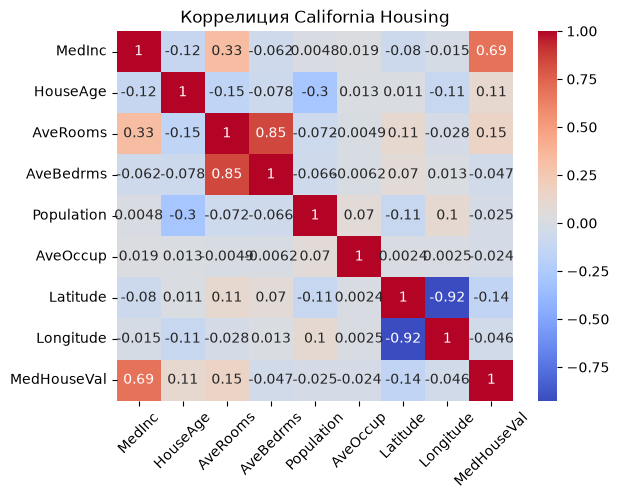

In [19]:
# твой код
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Коррелиция California Housing")
plt.show()

## Упражнение 3 — Split 80/20

**Что делаем:** раздели `df` на `X` (все фичи кроме `MedHouseVal`) и `y` (`MedHouseVal`). Через `train_test_split` с `test_size=0.2, random_state=42` сделай train/test. Выведи формы.

**Вход:** `df`.

**Ожидаемый выход:** `X_train` ~ 16 512 строк, `X_test` ~ 4 128 строк.


In [20]:
# твой код
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Упражнение 4 — Обучить baseline LinearRegression

**Что делаем:** обучи `LinearRegression` на `X_train, y_train`. Это будет baseline.

**Вход:** `X_train, y_train`.

**Ожидаемый выход:** обученная модель в переменной `model`.


In [21]:
# твой код
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


## Упражнение 5 — Коэффициенты и интерпретация

**Что делаем:** построй `pd.Series` коэффициентов с именами фичей, отсортируй по убыванию модуля, выведи. В комментарии напиши, какая фича влияет сильнее всего и какой знак.

**Вход:** `model, X.columns`.

**Ожидаемый выход:** Series длины 8 + строка-комментарий.


In [23]:
coefs = pd.Series(model.coef_, index=X.columns).round(4)
intercept = round(model.intercept_, 4)
print('Коэффициенты:')
print(coefs)
print(f'\nIntercept (b): {intercept}')

Коэффициенты:
MedInc        0.4487
HouseAge      0.0097
AveRooms     -0.1233
AveBedrms     0.7831
Population   -0.0000
AveOccup     -0.0035
Latitude     -0.4198
Longitude    -0.4337
dtype: float64

Intercept (b): -37.0233


## Упражнение 6 — Все 4 метрики на test

**Что делаем:** на `X_test, y_test` посчитай MAE, RMSE, MAPE, R². Округли до 3 знаков, выведи аккуратно.

**Вход:** `model, X_test, y_test`.

**Ожидаемый выход:** 4 числа.


In [25]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE:  {mae:.3f}   (средняя абс. ошибка в K единиц продаж)')
print(f'RMSE: {rmse:.3f}   (то же, но штрафует большие ошибки сильнее)')
print(f'MAPE: {mape:.3%}  (средняя ошибка в процентах от истинного значения)')
print(f'R²:   {r2:.3f}    (доля объяснённой дисперсии, 1 = идеал)')

MAE:  0.533   (средняя абс. ошибка в K единиц продаж)
RMSE: 0.746   (то же, но штрафует большие ошибки сильнее)
MAPE: 31.952%  (средняя ошибка в процентах от истинного значения)
R²:   0.576    (доля объяснённой дисперсии, 1 = идеал)


## Упражнение 7 — График y_true vs y_pred

**Что делаем:** на test построй scatter `y_true` vs `y_pred` + диагональ y=x красным. Подпиши оси, заголовок.

**Вход:** `y_test, y_pred`.

**Ожидаемый выход:** график.


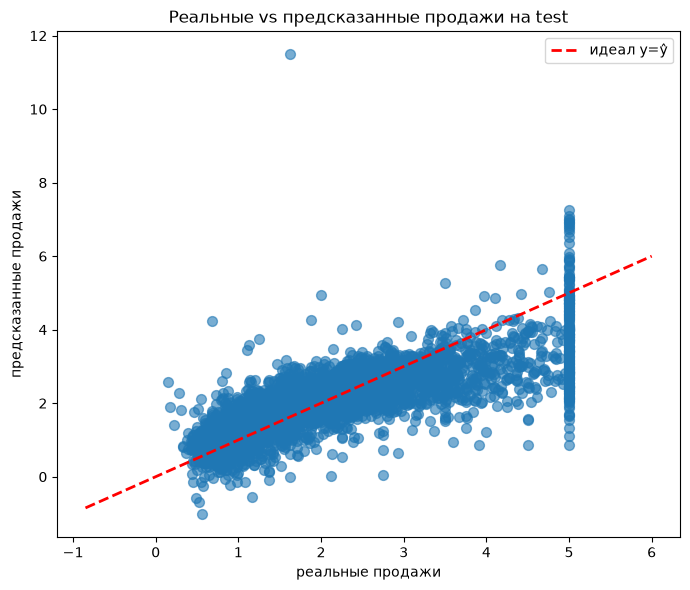

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.6, s=50)
lims = [y_test.min() - 1, y_test.max() + 1]
ax.plot(lims, lims, 'r--', lw=2, label='идеал y=ŷ')
ax.set_xlabel('реальные продажи')
ax.set_ylabel('предсказанные продажи')
ax.set_title('Реальные vs предсказанные продажи на test')
ax.legend()
plt.tight_layout()
plt.show()

## Упражнение 8 — Остатки

**Что делаем:** посчитай `residuals = y_test - y_pred`. Построй гистограмму остатков (30 бинов). Среднее остатков должно быть около 0.

**Вход:** `y_test, y_pred`.

**Ожидаемый выход:** график + строка с `residuals.mean()`.


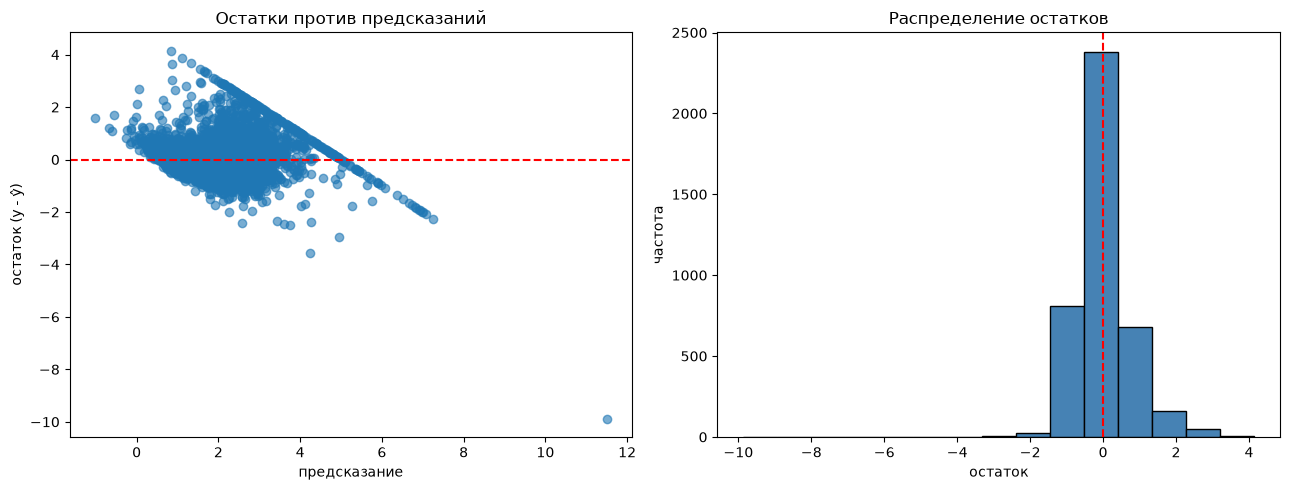

Среднее остатков: 0.003
std остатков:     0.746


In [28]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева: остатки vs предсказание.
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('предсказание')
axes[0].set_ylabel('остаток (y - ŷ)')
axes[0].set_title('Остатки против предсказаний')

# Справа: гистограмма остатков (должна быть похожа на нормальное распределение).
axes[1].hist(residuals, bins=15, edgecolor='black', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('остаток')
axes[1].set_ylabel('частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

print(f'Среднее остатков: {residuals.mean():.3f}')
print(f'std остатков:     {residuals.std():.3f}')

## Упражнение 9 — Polynomial degree=2

**Что делаем:** собери Pipeline `[StandardScaler, PolynomialFeatures(2, include_bias=False), LinearRegression]`. Обучи на train, посчитай RMSE на test. Сравни с baseline из упр. 6.

**Вход:** `X_train, y_train, X_test, y_test`.

**Ожидаемый выход:** одно число — RMSE poly(2).


In [30]:
# твой код
pipe2 = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
model2 = pipe2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'RMSE для полиномиальной регрессии: {rmse2:.3f}')
print(f'RMSE для линейной регрессии: {rmse:.3f}')

RMSE для полиномиальной регрессии: 0.681
RMSE для линейной регрессии: 0.746


## Упражнение 10 — K-fold сравнение трёх моделей

**Что делаем:** через `KFold(n_splits=5, shuffle=True, random_state=42)` и `cross_val_score(scoring='neg_root_mean_squared_error')` сравни три модели:
- baseline `LinearRegression`
- `Pipeline(StandardScaler, Poly(2), LinearRegression)`
- `Pipeline(StandardScaler, Poly(3), LinearRegression)`

Выведи mean ± std RMSE для каждой.

**Вход:** `X, y`.

**Ожидаемый выход:** 3 строки вида `baseline: 0.728 ± 0.012`.


In [31]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'baseline': LinearRegression(),
    'poly degree=2': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression(),
    ),
    'poly degree=3': make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        LinearRegression(),
    ),
}

results = []
for name, m in models.items():
    scores = -cross_val_score(
        m, X, y, cv=kf, scoring='neg_root_mean_squared_error'
    )
    results.append({
        'model': name,
        'rmse_mean': scores.mean(),
        'rmse_std': scores.std(),
    })

comparison = pd.DataFrame(results).round(3)
comparison

,model,rmse_mean,rmse_std
0,baseline,0.728,0.015
1,poly degree=2,1.065,0.669
2,poly degree=3,1.189,0.119


## Упражнение 11 — Выбор и финальное обучение

**Что делаем:** выбери лучшую модель из упр. 10 (по mean RMSE при адекватном std), обучи её на ВСЕХ данных (`X, y`), сохрани через `joblib.dump` в `/tmp/my_california.pkl`.

**Вход:** `X, y`.

**Ожидаемый выход:** файл на диске.


In [32]:
# твой код
model = LinearRegression()
model.fit(X, y)
joblib.dump(model, 'california_housing_model.pkl')

['california_housing_model.pkl']

## Упражнение 12 — Загрузить и предсказать новый район

**Что делаем:** загрузи модель из файла. Создай новый «район» как `pd.DataFrame` с одной строкой:

```python
new = pd.DataFrame([{
    'MedInc': 5.0, 'HouseAge': 25.0, 'AveRooms': 6.0, 'AveBedrms': 1.0,
    'Population': 1500.0, 'AveOccup': 3.0, 'Latitude': 34.0, 'Longitude': -118.0,
}])
```

Сделай `predict`, выведи цену в долларах (умножь на 100 000).

**Вход:** `joblib.load(...)`, `new`.

**Ожидаемый выход:** одно число (примерно 200 000 — 350 000 долл.).


In [37]:
# твой код
new = pd.DataFrame([{
    'MedInc': 5.0, 'HouseAge': 25.0, 'AveRooms': 6.0, 'AveBedrms': 1.0,
    'Population': 1500.0, 'AveOccup': 3.0, 'Latitude': 34.0, 'Longitude': -118.0,
}])
loaded_model = joblib.load('california_housing_model.pkl')
predictions = loaded_model.predict(new)
for i, pred in enumerate(predictions):
    print(f'Предсказанная стоимость дома для нового примера {i+1}: {pred*100_000:0,.0f} USD')

Предсказанная стоимость дома для нового примера 1: 240,918 USD
